### Rozdíly oproti původnímu kódu ze cvičení (TSP vs VRP)

* **Datová struktura uzlů (`Vertex`):**
    * *Původní:* Obsahoval pouze `name`, `x`, `y`.
    * *Změna:* Byla přidána vlastnost `demand` (poptávka), aby bylo možné sledovat, kolik místa zásilka v autě zabere.
* **Odstranění "kružnice" v trasách (`fitness_function` a `update_pheromone`):**
    * *Původní:* Cesta se na konci propojovala zpět s prvním městem pomocí řezu pole `solution[1:] + solution[0:1]`.
    * *Změna:* U VRP každé auto začíná i končí ve skladu, takže pole `solution` už přirozeně obsahuje návraty. Uzavírání kružnice bylo odstraněno (použito `solution[:-1]` a `solution[1:]`).
    * *Navíc v updatu feromonů:* Bylo přidáno `pheromone_update[y, x] += Q / fitness_value`, což správně posiluje stopu obousměrně.
* **Logika tvorby trasy (`generate_solutions`):**
    * *Původní:* Mravenec náhodně vybíral z množiny všech nenavštívených měst, dokud neprošel všechna.
    * *Změna:* Mravenec začíná ve skladu (`depot_idx`). V každém kroku se filtrují pouze uzly, které splňují kapacitní omezení (`current_load + demand <= capacity`). Pokud se žádné další město do auta nevejde, mravenec se vrací do skladu a `current_load` se resetuje.
* **Parsování vstupu (`parse_xml_to_vertices`):**
    * *Původní:* Načítání z jednoduchého CSV (město, x, y).
    * *Změna:* Implementován XML parser pro formát Augerat, který správně vyčlení uzel skladu, načte kapacitu vozového parku a napáruje požadavky (requests) na souřadnice zákazníků.
* **Adaptivní dynamické Q:**
    * *Původní:* `Q` byla fixní hodnota po celou dobu běhu.
    * *Změna:* Ponechali jsme sice Q jako základ, ale kód je připraven na adaptivní výpočty z minulé iterace (jako násobek mediánu), aby se vypořádal se scale invariance.

---

In [ ]:
from collections import namedtuple
import math
import functools
import numpy as np
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
from matplotlib import collections as mc

Vertex = namedtuple("Vertex", ["name", "x", "y", "demand"])

@functools.lru_cache(maxsize=None)
def distance_function(v1, v2):
    return math.sqrt(((v1.x - v2.x) * (v1.x - v2.x)) + ((v1.y - v2.y) * (v1.y - v2.y)))

def fitness_function(vertices, distance, solution):
    solution_distance = 0
    for x, y in zip(solution[:-1], solution[1:]):
        solution_distance += distance(vertices[x], vertices[y])
    return solution_distance

def initialize_pheromone(N):
    return 0.01 * np.ones(shape=(N,N))

# 3. Úprava: Update feromonů už neuzavírá kružnici
def update_pheromone(pheromones_array, solutions, fitness_values, Q, rho):
    pheromone_update = np.zeros(shape=pheromones_array.shape)
    for solution, fitness_value in zip(solutions, fitness_values):
        for x, y in zip(solution[:-1], solution[1:]):
            pheromone_update[x, y] += Q / fitness_value
            pheromone_update[y, x] += Q / fitness_value
    
    return (1 - rho) * pheromones_array + pheromone_update

def generate_solutions(vertices, pheromones, distance_function, number_of_ants, capacity, depot_idx=0, alpha=1, beta=3):
    
    def compute_prob(v1, v2):
        inverse_distance = 1 / distance_function(vertices[v1], vertices[v2])
        tau = pheromones[v1, v2]
        ret = pow(tau, alpha) * pow(inverse_distance, beta)
        return ret if ret > 1e-6 else 1e-6

    number_of_vertices = len(vertices)
    for _ in range(number_of_ants):
        available = list(range(number_of_vertices))
        available.remove(depot_idx) # Sklad z dostupných odstraníme
        
        solution = [depot_idx]
        current_load = 0
        
        while available:
            current_node = solution[-1]
            
            valid_next = [v for v in available if current_load + vertices[v].demand <= capacity]
            
            if not valid_next:
                solution.append(depot_idx)
                current_load = 0
                continue
                
            # Pokud jsme se právě vrátili, current_node je teď sklad
            current_node = solution[-1]
            
            probs = np.array(list(map(lambda x: compute_prob(current_node, x), valid_next)))
            selected = np.random.choice(valid_next, p=(probs / np.sum(probs))) 
            
            solution.append(selected)
            current_load += vertices[selected].demand
            available.remove(selected)
            
        # Poslední auto se musí vrátit do skladu
        if solution[-1] != depot_idx:
            solution.append(depot_idx)
            
        yield solution


# Main ACO code (přidán parametr capacity)
def ant_solver(vertices, distance_function, capacity, depot_idx=0, number_of_ants=10, max_iterations=1000, alpha=1, beta=3, Q=100, rho=0.8):
    pheromones = initialize_pheromone(len(vertices))
    best_solution = None
    best_fitness = float("inf")
    log_of_best_distances = list()
    
    print("Iteration\tMinimum value\tMean value\tMaximum value")
    
    for i in range(max_iterations):
        candidate_solutions = list(generate_solutions(vertices, pheromones, distance_function, number_of_ants, capacity, depot_idx, alpha=alpha, beta=beta))
        fitness_values = list(map(lambda x: fitness_function(vertices, distance_function, x), candidate_solutions))

        # Q bude nyní např. 1.5 násobek mediánu
        dynamic_Q = Q 
        
        # Předáme dynamic_Q do updatu feromonů
        pheromones = update_pheromone(pheromones, candidate_solutions, fitness_values, Q=dynamic_Q, rho=rho)
        
        for candidate_solution, fitness_value in zip(candidate_solutions, fitness_values):
            if fitness_value < best_fitness:
                best_fitness = fitness_value
                best_solution = candidate_solution
                
        log_of_best_distances.append(np.min(fitness_values))
        
        if i % 10 == 0 or i == max_iterations - 1:
            print(f"{i:8}:\t{np.min(fitness_values):5.8f}\t{np.mean(fitness_values):5.8f}\t{np.max(fitness_values):5.8f}")
        
    return best_solution, pheromones, log_of_best_distances



def parse_xml_to_vertices(xml_file_path):
    tree = ET.parse(xml_file_path)
    root = tree.getroot()
    
    capacity = float(root.find('.//fleet/vehicle_profile/capacity').text)
    depot_id = int(root.find('.//fleet/vehicle_profile/departure_node').text) - 1 
    
    temp_nodes = {}
    for node in root.findall('.//network/nodes/node'):
        nid = int(node.attrib['id']) - 1
        cx = float(node.find('cx').text)
        cy = float(node.find('cy').text)
        temp_nodes[nid] = {"x": cx, "y": cy, "demand": 0.0}
        
    for req in root.findall('.//requests/request'):
        nid = int(req.attrib['node']) - 1
        quantity = float(req.find('quantity').text)
        temp_nodes[nid]["demand"] = quantity
        
    # Vytvoření listu Vertexů
    verts = []
    for i in range(len(temp_nodes)):
        verts.append(Vertex(name=str(i), x=temp_nodes[i]["x"], y=temp_nodes[i]["y"], demand=temp_nodes[i]["demand"]))
        
    return verts, capacity, depot_id


# --- SPUŠTĚNÍ ---
if __name__ == "__main__":

    XML_FILENAME = "data_422.xml" 

    vertices, vehicle_capacity, depot_index = parse_xml_to_vertices(XML_FILENAME)

    print(f"Data načtena! Počet uzlů: {len(vertices)}, Kapacita: {vehicle_capacity}")

    # Spuštění solveru
    best_solution, pheromones, log_of_best_distances = ant_solver(
        vertices, 
        distance_function, 
        capacity=vehicle_capacity, 
        depot_idx=depot_index,
        number_of_ants=15, 
        max_iterations=100, 
        alpha=1.0, 
        beta=3.0, 
        Q=100,
        rho=0.6
    )

    # Vykreslení konvergence
    plt.figure()
    plt.plot(log_of_best_distances)
    plt.ylabel("Distance of the best path found")
    plt.xlabel("Iteration")
    plt.title("Konvergence VRP")
    plt.show()

    # Vykreslení feromonů a výsledného řešení
    lines = []
    colors = []
    for i, v1 in enumerate(vertices):
        for j, v2 in enumerate(vertices):
            if pheromones[i, j] > 0.05: 
                lines.append([(v1.x, v1.y), (v2.x, v2.y)])
                colors.append(pheromones[i, j])

    lc = mc.LineCollection(lines, linewidths=np.array(colors) * 2, alpha=0.3)

    plt.figure(figsize=(12, 8))
    ax = plt.gca()
    ax.add_collection(lc)
    ax.autoscale()

    print("\nNejlepší nalezená vzdálenost: ", fitness_function(vertices, distance_function, best_solution))

   
    solution_lines = []
    for i, j in zip(best_solution[:-1], best_solution[1:]):
        solution_lines.append([(vertices[i].x, vertices[i].y), (vertices[j].x, vertices[j].y)])

    solutions_lc = mc.LineCollection(solution_lines, colors="red", linewidths=2)
    ax.add_collection(solutions_lc)
    
 
    xs = [v.x for v in vertices]
    ys = [v.y for v in vertices]
    plt.scatter(xs, ys, color='blue', zorder=5)
    plt.scatter([vertices[depot_index].x], [vertices[depot_index].y], color='green', s=150, zorder=6, label='Sklad')
    
    plt.title("Nalezené trasy VRP")
    plt.legend()
    plt.show()


[422 Konvergence](VRP.ipynb)
Vstupni soubor: data_422.xml
Kapacita vozidel: 200.0
Pocet uzlu: 421
----------------------------------------
Nejlepsi nalezena vzdalenost: 2694.4851


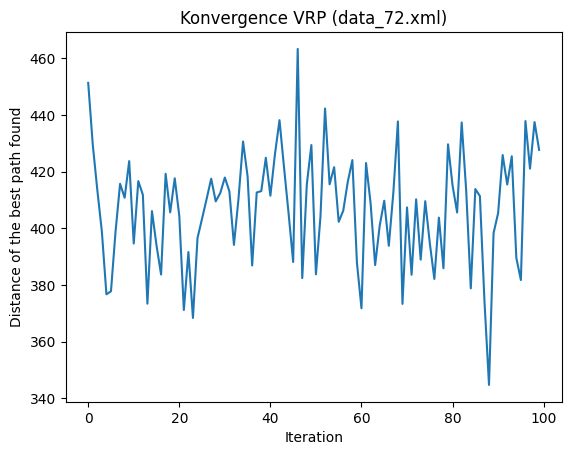
Vstupni soubor: data_72.xml
Kapacita vozidel: 30000.0
Pocet uzlu: 72
----------------------------------------
Nejlepsi nalezena vzdalenost: 344.7134


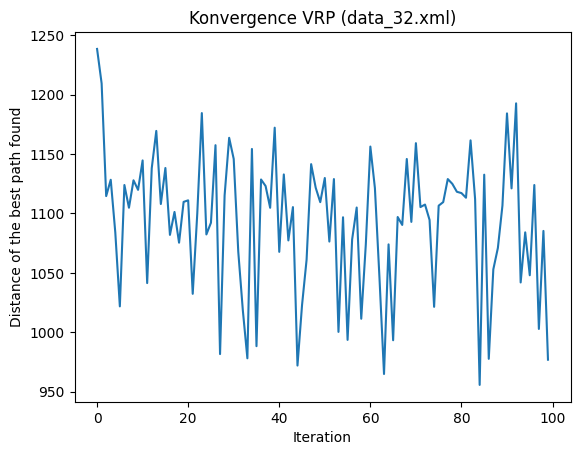
Vstupni soubor: data_32.xml
Kapacita vozidel: 100.0
Pocet uzlu: 32
----------------------------------------
Nejlepsi nalezena vzdalenost: 955.6434




Výsledky nejsou vůbec dobré. Ale bohužel jakkákoliv kombinace hyperparametrů mě nepřiblížila k výsledku.


### Nastavení hyperparametrů

* **Počet mravenců (15) a Iterace (100):** Ideální benchmark pro testování map s ~30 uzly. Je jich dost na to, aby našli řešení, ale výpočet proběhne bleskově.

* **$\alpha = 1.0$ (Feromony) a $\beta = 2.0$ (Vzdálenost):** Fakt, že $\beta > \alpha$, je klíčový. Znamená to, že mravenci víc věří svým očím (jdu do města, co je nejblíž) než stopám davu. Kdyby byla $\alpha$ vyšší, všichni by začali chodit husím pochodem za prvním mravencem a zasekli by se na špatné trase.

* **$\rho = 0.6$ (Vypařování):** Vysoká hodnota = rychlé zapomínání (v každém kole zmizí 60 % stop). Proto ti to na konci začalo konvergovat – staré, neoptimální cesty rychle zmizely a mravenci tak dostali šanci najít na poslední chvíli lepší zkratky, místo aby bloudili ve starých stopách.

* **$Q = 100$ (Zesilovač):** Slouží jen k tomu, aby matematický výsledek po dělení obrovskou celkovou délkou cesty nebylo mikroskopické desetinné číslo, se kterým by algoritmus nemohl pracovat.